<a href="https://colab.research.google.com/github/mcjkurz/qhchina/blob/main/tutorials/Intro_to_Python_for_Chinese_Humanities_Part_2_Working_with_Texts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Python for Chinese Humanities: Part 2, Working with Texts

## Reading text files

Let's first download a text file, a novella *Love in a Fallen City* by Eileen Chang 张爱玲, using the special command `wget`.

You can upload your own text (needs to be a .txt file). To do that, simply click the folder icon (文件夾) on the left side and drag the file from your computer there. It should not be too big.

In [1]:
!wget https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/张爱玲_倾城之恋.txt

--2024-06-18 10:44:34--  https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/%E5%BC%A0%E7%88%B1%E7%8E%B2_%E5%80%BE%E5%9F%8E%E4%B9%8B%E6%81%8B.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 86846 (85K) [text/plain]
Saving to: ‘张爱玲_倾城之恋.txt.2’

张爱玲_倾城之恋.txt 100%[===================>]  84.81K  --.-KB/s    in 0.02s   

2024-06-18 10:44:34 (3.72 MB/s) - ‘张爱玲_倾城之恋.txt.2’ saved [86846/86846]



We use the `open` function to read files.

`open` takes two arguments: the name of the file and the mode of access to this file.

Here, we use `r` for "read." We need to remember to `close` the file after we finish reading from it.

**Remember to use a correct filename if you use your own text. Here, we use "张爱玲_倾城之恋.txt"**.

In [2]:
# Option 1
filename = "张爱玲_倾城之恋.txt" # change to your own filename!

my_file = open(filename, "r")
text = my_file.read()
my_file.close()

In [3]:
# Option 2 (recommended)
filename = "张爱玲_倾城之恋.txt" # change to your own filename!
with open(filename, "r") as my_file:
  text = my_file.read()

In [4]:
print("How many characters (including spaces):", len(text))

How many characters (including spaces): 29139


In [5]:
print(text[:200]) # print the first 200 characters

《倾城之恋》

作者：张爱玲

上海为了“节省天光”，将所有的时钟都拨快了一个小时，然而白公馆里说：“我们用的是老钟。”他们的十点钟是人家的十一点。他们唱歌唱走了板，跟不上生命的胡琴。

胡琴咿咿呀呀拉着，在万盏灯的夜晚，拉过来又拉过去，说不尽的苍凉的故事——不问也罢！……胡琴上的故事是应当由光艳的伶人来扮演的，长长的两片红胭脂夹住琼瑶鼻，唱了，笑了，袖子挡住了嘴……然而这里只有白四爷单身坐在黑沉


## Word segmentation for Chinese

Unlike English, in Chinese there are no spaces between words. This is a problem for word analysis.

For very short texts, we can segment them into separate words ourselves.

In [6]:
text = "我今天很開心。"
word_list = ["我", "今天", "很", "開心","。"]
print(len(word_list))

5


In [7]:
for word in word_list:
  print(word)

我
今天
很
開心
。


In [8]:
for character in text:
  print(character)

我
今
天
很
開
心
。


For larger texts, however, we need some help.

Fortunately, there are free, open-source models that we can use to segment Chinese texts.

In this example, we will use `spacy` model for Chinese, `zh_core_web_lg`.

Let's first download and load the model. It might take around 30 seconds.

In [9]:
!python -m spacy download zh_core_web_lg
import spacy
nlp = spacy.load("zh_core_web_lg")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 603.0/603.0 MB 885.8 kB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('zh_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Let's now segment our short sentence ("我今天很開心") using the model we have just downloaded.

To do that, we can use the function `nlp` and provide the text as the argument.

The function `nlp` will return a list of tokens (words). Each token in this list has some important properties. We will use two of them:

*   `token.text` -- this is the actual word
*   `token.pos_` -- this is the part-of-speech tag (noun, verb, etc).

Let's try!


In [10]:
sentence = "我今天很開心。"

segmented_sentence = nlp(sentence) # this will return a list of tokens
print([token.text for token in segmented_sentence]) # let's print a list of words

['我', '今天', '很', '開心', '。']


**Part-of-Speech (POS)** is a very useful category. For example, we might want to remove all punctuation marks (。，“； etc.) from our list of words.

Each token has its tag (called POS-tag). The full list of tags can be seen here: https://universaldependencies.org/u/pos/

In [11]:
print([token.pos_ for token in segmented_sentence])

['PRON', 'NOUN', 'ADV', 'VERB', 'PUNCT']


The model is roughly correct.
* "我" is a pronoun (PRON),
* "今天" is a noun (NOUN),
* "很" is an adverb (ADV),
etc.

Let's now go back to our text. We will segment it into separate tokens.

Then, we will remove punctuation and some "unwanted" tokens that the model identified wrongly (models often mistakes). *See also the warning below!*

In [12]:
# reading the text from file
f = open(filename, "r")
text = f.read()
f.close()

segmented_text = nlp(text)

print("Originally, there were", len(segmented_text), "tokens, including spaces and punctuation.")

forbidden_tags = ["PUNCT", "PROPN", "SYM", "SPACE"] # the tags we want to remove (can add yours; maybe you want to focus on verbs only?)
forbidden_words = ["金枝","流苏","姓范","白老","老太太","方道"] # words that we want to remove (you can add yours)

# we keep only the tokens that are not punctuation, proper nouns, symbols, and spaces
# we also remove the "forbidden words" which were wrongly tagged/segmented
# we use list comprehension
text_tokens = [token.text for token in segmented_text if token.pos_ not in forbidden_tags and token.text not in forbidden_words]

print("There are", len(text_tokens), "after cleaning.")
print(text_tokens[:10]) # print first 10 tokens

Originally, there were 20220 tokens, including spaces and punctuation.
There are 15449 after cleaning.
['作者', '为了', '节省', '天光', '将', '所有', '的', '时钟', '都', '拨']


It looks like we have removed almost 5,000 words! These included punctuation, spaces, symbols (%^&# etc.), and proper names.

**WARNING:** *If you are working with poetry or some other text that should be split (分詞) by characters rather than words, you can use the following code. Please remove the comment symbol (#) before running it.*

In [13]:
# filename = "text.txt" # change the filename
# f = open(filename, "r")
# text = f.read()
# f.close()
#
# forbidden_chars = [] # define your own forbidden characters
# text_tokens = [token.strip() for token in text] # segment by characters rather than words
# text_tokens = [token for token in text_tokens if len(token) > 0 and token not in forbidden_chars]

## Finding most common and most informative (interesting) words

Now, let's find the most frequent tokens in Eileen Chang's novel.

We will use the library `collections` and the class `Counter` from this library.

We can use `Counter` as a function, providing the text_tokens as its argument.

In [14]:
from collections import Counter

token_counter = Counter(text_tokens)
token_counter.most_common(20) # print the 20 most common tokens

[('的', 862),
 ('了', 641),
 ('她', 392),
 ('一', 242),
 ('是', 241),
 ('着', 239),
 ('你', 215),
 ('我', 195),
 ('不', 191),
 ('在', 187),
 ('他', 182),
 ('也', 127),
 ('上', 114),
 ('人', 103),
 ('就', 103),
 ('里', 97),
 ('那', 95),
 ('柳原', 93),
 ('太太', 89),
 ('去', 89)]

We see that some of the most frequent words are the so-called "function words": 的, 了, 是, 著, etc.

We can check how many times a token shows up by just looking up its value in the dictionary `token_counter`.

In [15]:
print(token_counter["她"])
print(token_counter["abc"]) # "abc" should appear 0 times

392
0


Usually, the words that appear most often, such as 的 or 了, are not the most interesting ones.

They have grammatical functions but little semantic meaning.

The problem is: we need to find the words that appear not most often but **more often than expected.**

Such words are usually much more interesting.

Each word in a language has a certain average probability of occurring.

How to calculate this probability? We should divide the number of appearances by the total number of words.

If there are **10** words in total, and a word "hamburger" appears **3** times, its probability is **3/10 = 0.3 = 30%**.

Let's see another example, this time with Python.

In [16]:
word_list = ["我","今天","很","开心","我"] # notice the second 我 added at the end

number_of_words = len(word_list)

count_of_我 = word_list.count("我")

print("There are " + str(number_of_words) + " words in the list and the word 我 appears " + str(count_of_我) + " times.")

normalized_count = count_of_我 / number_of_words

print("Its probability is " + str(normalized_count) + ".")

There are 5 words in the list and the word 我 appears 2 times.
Its probability is 0.4.


We can repeat this for each unique word in the list.

To get unique words, we use the `set()` function which changes the list into a set.

A `list` can contain many identical elements.

**A `set` contains only unique (different) elements!**

In [17]:
my_list = [1,1,1,2,3,4,4]

my_set = set(my_list)

print(my_set)

{1, 2, 3, 4}


Now let's calculate the probability of each unique word in a list.

We want a list of tuples, where each tuple contains two elements: `(word, probability)`.

In [18]:
word_list = ["我","今天","很","开心","我"]

number_of_words = len(word_list)

word_set = set(word_list)

probabilities = [] # let's start with an empty list

# for each unique word, calculate its probability by dividing its count by the number of all words in the list

for word in word_set:

  count = word_list.count(word)

  probability = count / number_of_words

  print("Word " + word + " appears " + str(count) + " time(s). Its probability is " + str(probability) + ".")

  probabilities.append((word, probability)) # append the tuple (word, probability) to the list

print(probabilities)

Word 今天 appears 1 time(s). Its probability is 0.2.
Word 我 appears 2 time(s). Its probability is 0.4.
Word 开心 appears 1 time(s). Its probability is 0.2.
Word 很 appears 1 time(s). Its probability is 0.2.
[('今天', 0.2), ('我', 0.4), ('开心', 0.2), ('很', 0.2)]


We can achieve the same result using list comprehension.

In [19]:
probabilities = [(word, word_list.count(word)/number_of_words) for word in word_set]
print(probabilities)

[('今天', 0.2), ('我', 0.4), ('开心', 0.2), ('很', 0.2)]


We can do the same for a large corpus of texts, not just our one sentence.

We need to do that because we want to know the (average) probability of each word in the Chinese language.

We can then compare these "global" probabilities with Eileen Chang's word usage, and see how the two are different from each other.

In other words, the question is: *how is Eileen Chang's novel different from an average Chinese text?*

Fortunately, the "global" probabilities have already been calculated by other scholars.

Let's download them now.

In [20]:
!wget https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/chinese_word_freqs.json
import json
with open("chinese_word_freqs.json", "r") as f:
  global_probs = json.load(f)

--2024-06-18 10:45:46--  https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/chinese_word_freqs.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7541058 (7.2M) [text/plain]
Saving to: ‘chinese_word_freqs.json.6’

chinese_word_freqs. 100%[===================>]   7.19M  --.-KB/s    in 0.1s    

2024-06-18 10:45:46 (54.2 MB/s) - ‘chinese_word_freqs.json.6’ saved [7541058/7541058]



What is the probability of the word "我" in an average Chinese text?

In [21]:
global_probs["我"]

0.010069128495994678

This means the word "我“ appears with the probability 0.01 (or 1%).

For every 100 Chinese words, there should be at least one "我" on average.

Let's go back to our novel now and find how many words are there in total, excluding the puncutation, proper nouns, etc.

As you remember, we generated the list `text_tokens` by removing some "forbidden words" and the words with forbidden POS tags.

In [22]:
total_tokens_in_text = len(text_tokens)
print("There are", total_tokens_in_text, "words in 'Love in a Fallen City.'")

There are 15449 words in 'Love in a Fallen City.'


Now, we know that the word "我" should appear in ≈1% of them.

Why? Because *Love in a Fallen City* is written in Chinese, and on average 1% of words in Chinese texts are "我". This is the global probability of the word "我".

It means that **"我" should appear around 0.01 * 15,449 times, or ≈154 times** in the novel.

It should, but maybe it appears more often. Let's check.


In [23]:
should_appear_times = global_probs["我"] * total_tokens_in_text
appear_times = token_counter["我"]

print("The word 我 should appear", should_appear_times, "times in the text. In fact, it appears", appear_times, "times.")
print("It appears", appear_times/should_appear_times, "times more often than it should.")

The word 我 should appear 155.55796613462178 times in the text. In fact, it appears 195 times.
It appears 1.2535520028028948 times more often than it should.


1.2535 is not a big value. Nevertheless, it is an interesting finding.

We have found that 我 appears more often than expected in *Love in a Fallen City*.

Let's repeat this process for every unique word in the novel.

We need to first find the unique words. We can use the `set()` function.

In [24]:
text_unique_tokens = set(text_tokens)
print("There are", len(text_unique_tokens), "unique tokens in our text.")

There are 4549 unique tokens in our text.


Now, we will check which of these unique words appears much more often than expected in the text.

To do that, we need to calculate how many times each word appears in the novel and how many times it *should* appear. We will then divide the two values.

We will store the results of these calculations in a dictionary `token_ratios_dict`.

Please spend some time to understand the following piece of code. It might seem difficult at first.

In [25]:
token_ratios_dict = {}

for unique_token in text_unique_tokens: # for each unique word in the text

  if unique_token in global_probs.keys(): # check if the word appears in the global_freqs dictionary ("average Chinese" probabilities)

    # calculate how many times it should appear given its "average" global Chinese probability
    should_appear = global_probs[unique_token] * total_tokens_in_text

    # find how many times it actually appears in the text
    appears = token_counter[unique_token]

    # divide the two values
    token_ratios_dict[unique_token] = appears / should_appear # let's store the ratio for each word in the dictionary

# Let's check if our value is confirmed.
token_ratios_dict["我"]

1.2535520028028948

Let's explain this procedure again.

Each key-value pair in the `token_ratios_dict` dictionary tells us **how many times more often (or less often) a given word appears in the text than it "should."**

Let's check the pronoun 她: does it appear more (`value > 1`) or less often (`value < 1`) than it "should"?

In [26]:
token_ratios_dict["她"]

15.993546950484703

Wow! *Love in a Fallen City* really likes to use the feminine pronoun.

Eileen Chang uses 她 almost 16 times more often than an average Chinese text.

Now, let's sort the terms in decreasing order, from the highest to the lowest ratio.

We will use the function `sorted()` to achieve that.

Don't worry if you don't fully understand the code below, the most important is to know that it returns a list of sorted tuples.

Each tuple contains two values: `(word, ratio)`.

In [27]:
# dictionaries cannot be sorted; we need to first change the dictionary into a list of tuples (token, ratio)
token_ratios_list = token_ratios_dict.items()

# We now take the second element (elem[1]) from each tuple as the key by which to sort them (second element in each tuple is the ratio)
# We place the minus before it (-elem[1]) to make the descending order, i.e., from largest to smallest.
token_ratios_list = sorted(token_ratios_list, key = lambda elem:-elem[1])
token_ratios_list[:20] # top 10 elements

[('开仗', 3431.491646545342),
 ('吊子', 2846.86714380058),
 ('容得', 2341.777811835961),
 ('胡琴', 2028.4832358240376),
 ('刺挠', 1947.9904874842966),
 ('一男半女', 1709.46104003724),
 ('思道', 1665.0255084154771),
 ('下劲', 1637.4837330883036),
 ('绝子绝孙', 1589.6739890565284),
 ('徐太太', 1555.6095464338887),
 ('承情', 1495.778410032585),
 ('带累', 1479.51994905397),
 ('蔻丹', 1412.3562678388093),
 ('寒苦', 1388.9370950302575),
 ('个人主义者', 1276.5846219269895),
 ('舞场', 1218.3113476210806),
 ('递信', 1212.6132321867726),
 ('阔人', 1191.3858670719057),
 ('忠孝节义', 1115.7035681390594),
 ('扫帚星', 1103.269181868006)]

The word "胡琴" appears 2028 times more often than expected! That's very surprising.

We see another problem, however. Phrases like "开仗" or "一男半女" might be very rare in the text, but even rarer in the global corpus ("average Chinese"), which pushes them up the hierarchy. **A word that appears only once or twice in a text can be very surprising (appear much more often than expected), and yet it may not be representative of the text.**

We need to find a balance between the word's rarity and its informativeness.

Let's filter this list, then, and retain only the elements that are present in the novel at least 4 times. This number is arbitrary. You can play with this value to achieve slightly different results to better understand the vocabulary of the text.

In [28]:
min_frequency = 4

token_ratios_list = [(token, ratio) for token, ratio in token_ratios_list if token_counter[token] >= min_frequency]
token_ratios_list[:10]

[('胡琴', 2028.4832358240376),
 ('舞场', 1218.3113476210806),
 ('太太', 368.28045457348645),
 ('堂屋', 318.93583730064347),
 ('好容易', 144.39125936534137),
 ('发胖', 82.2964976290908),
 ('搁', 80.50533651791825),
 ('方才', 74.32992762934268),
 ('顽固', 73.57115617213174),
 ('窗子', 72.45503243753556)]

That's it! We have found some of the most characteristic words of the novel.

Terms such as 胡琴 (huqin), 舞场 (dance floor), 太太 (lady), 堂屋 (dining room) constitute some of the most important images of *Love in a Fallen City*.

We can now use these words in the next part of the project (e.g., close reading).

We can also visualize them. Let's make a wordcloud.

## Making a wordcloud from the informative words

We need to first download the Chinese font, as Python does not support Chinese language visualization by default.

In [29]:
!wget https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/STSong.ttf

--2024-06-18 10:45:47--  https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/STSong.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11697600 (11M) [application/octet-stream]
Saving to: ‘STSong.ttf.2’

STSong.ttf.2        100%[===================>]  11.16M  --.-KB/s    in 0.1s    

2024-06-18 10:45:47 (96.8 MB/s) - ‘STSong.ttf.2’ saved [11697600/11697600]



You can read more about the WordCloud class here: https://amueller.github.io/word_cloud/generated/wordcloud.WordCloud.html

You can choose different color maps: https://matplotlib.org/stable/gallery/color/colormap_reference.html

The following code will generate a wordcloud and save it as "wordcloud.png" in the local directory. You can download it to your computer.

If you don't like the final result, you can run the code as many times as you wish.

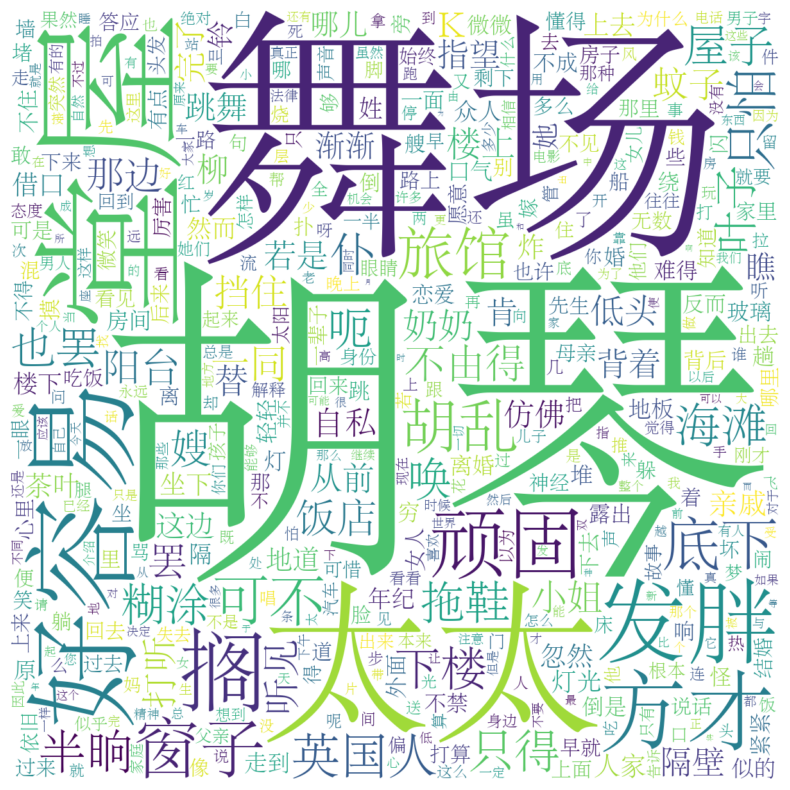

In [30]:
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from PIL import Image

# Convert back to a dictionary (WordCloud requires a dictionary)
frequencies_dict = dict(token_ratios_list)

# Generate word cloud
wordcloud = WordCloud(font_path='STSong.ttf', colormap="viridis", max_words=500, width=1200, height=1200, background_color='white')

wordcloud.generate_from_frequencies(frequencies_dict)

# Display the generated word cloud
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig("wordcloud.png", format="png", dpi=300, bbox_inches="tight")
plt.show()

We can also use a mask to give the wordcloud a specific shape or change the color palette. Here, I use the mask in the shape of a woman silhouette. I use the colormap `plasma`.

The generation will take much longer though (around 2 mins for these particular settings!)

After generation, you should download the file ("wordcloud_masked.png").

--2024-06-18 10:46:12--  https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/woman_silhouette.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 316910 (309K) [image/png]
Saving to: ‘woman_silhouette.png.1’

woman_silhouette.pn 100%[===================>] 309.48K  --.-KB/s    in 0.04s   

2024-06-18 10:46:13 (6.88 MB/s) - ‘woman_silhouette.png.1’ saved [316910/316910]



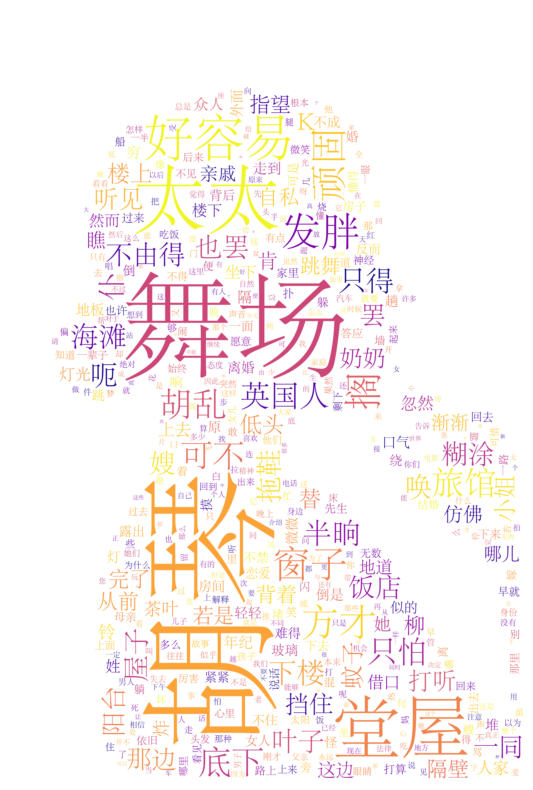

In [31]:
!wget https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/woman_silhouette.png
mask = np.array(Image.open('woman_silhouette.png'))

# Generate word cloud
wordcloud = WordCloud(font_path='STSong.ttf', mask=mask, colormap='plasma', max_words=500, width=1200, height=1200, background_color='white')
wordcloud.generate_from_frequencies(frequencies_dict)

# Display the generated word cloud
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig("wordcloud_masked.png", format="png", dpi=300, bbox_inches="tight")
plt.show()